In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.linear_model import LogisticRegression
from scipy.optimize import curve_fit
from scipy.special import expit

In [9]:
def plot_rt_by_condition(df, subject_id):

    df[['people_saved', 'people_fall']] = df['option1'].str.extract(r'save (\d+) (?:people|person), while (\d+) (?:people|person)')
    df['people_saved'] = df['people_saved'].astype(float)
    df['people_fall'] = df['people_fall'].astype(float)
    df['ratio'] = df['people_saved'] / df['people_fall'].replace(0, float('nan'))
    df["value-difference"] = df['people_saved'] - df['people_fall']

    df['EV1'] = df['people_saved']  # 100% chance
    df['EV2'] = 0.5 * (df['people_saved'] + df['people_fall'])  # 50% chance to save all
    df['chose_risky'] = (df['choice_key'] == 2).astype(int)
    df['ev_diff'] = df['EV1'] - df['EV2']  # signed, not absolute, so direction matters
    df['ev_bin'] = pd.cut(df['ev_diff'], bins=10)

    psychometric = df.groupby('ev_bin')['chose_risky'].mean().reset_index()
    psychometric['ev_mid'] = psychometric['ev_bin'].apply(lambda x: x.mid)  # bin midpoints for plotting
    psychometric['ev_mid'] = psychometric['ev_mid'].astype(float)

    df = df.dropna(subset=['ratio', 'rt', 'choice_key'])  # drop NaN rows in place

    # rt distribution
    plt.figure(figsize=(6, 4))
    sns.histplot(df['rt'], bins=30, kde=True, color='skyblue')
    plt.title('Distribution of Reaction Times')
    plt.xlabel('Reaction Time (ms)')
    plt.ylabel('Frequency')
    plt.savefig(f'/usr/people/ad3758/neu502b/analysis/behavioral_analysis/figures/{subject_id}/rt_distribution.png')
    plt.show()
    
    # rt over duration of experiment 
    plt.figure(figsize=(10, 2))
    sns.lineplot(x='trial', y='rt', data=df, color='purple')
    plt.title('Reaction Time over Trials')
    plt.xlabel('Trial Number')
    plt.ylabel('Reaction Time (ms)')
    plt.savefig(f'/usr/people/ad3758/neu502b/analysis/behavioral_analysis/figures/{subject_id}/rt_over_trials.png')
    plt.show()

    # reaction time by condition
    plt.figure(figsize=(4, 4))
    sns.boxplot(x='choice_key', y='rt', data=df, palette='Set2')
    plt.title('Reaction Time by Condition')
    plt.xlabel('Condition')
    plt.ylabel('Reaction Time (ms)')
    plt.savefig(f'/usr/people/ad3758/neu502b/analysis/behavioral_analysis/figures/{subject_id}/rt_by_condition.png')
    plt.show()

    # are rts significantly different by condition?
    from scipy.stats import ttest_ind
    rt_condition1 = df[df['choice_key'] == 1]['rt']
    rt_condition2 = df[df['choice_key'] == 2]['rt']
    t_stat, p_value = ttest_ind(rt_condition1, rt_condition2)
    print(f'T-statistic: {t_stat:.2f}, P-value: {p_value:.4f}')


    # fit a linear regression model to predict rt from ratio and condition
    
    df['intercept'] = 1
    model = sm.OLS(df['rt'], df[['intercept', 'ratio', 'choice_key']])
    results = model.fit()
    print(results.summary())

    # fit logistic regression to find decision boundary on ratio
    clf = LogisticRegression()
    clf.fit(df[['ratio']].values, df['choice_key'].values)
    boundary = -clf.intercept_[0] / clf.coef_[0][0]
    print(f'Decision boundary (ratio): {boundary:.3f}')

    # fit logistic regression to find decision boundary on value difference
    clf_diff = LogisticRegression()
    clf_diff.fit(df[['value-difference']].values, df['choice_key'].values)
    boundary_diff = -clf_diff.intercept_[0] / clf_diff.coef_[0][0]
    print(f'Decision boundary (value difference): {boundary_diff:.3f}')

    # fit logistic regression to find decision boundary on rt and ratio
    clf_rt_ratio = LogisticRegression()
    clf_rt_ratio.fit(df[['rt', 'ratio']].values, df['choice_key'].values)
    boundary_rt_ratio = -clf_rt_ratio.intercept_[0] / clf_rt_ratio.coef_[0][1]
    print(f'Decision boundary (rt and ratio): {boundary_rt_ratio:.3f}')

    # plot rt by value difference colored by condition
    plt.figure(figsize=(6, 4))
    sns.scatterplot(x='value-difference', y='rt', data=df, hue='choice_key')
    sns.regplot(x='value-difference', y='rt', data=df, scatter=False, color='gray')
    plt.axvline(x=boundary_diff, color='red', linestyle='--', label=f'Decision boundary: {boundary_diff:.2f}')
    plt.title('Reaction Time vs. People Saved - People Fall Difference')
    plt.xlabel('Value Difference')
    plt.ylabel('Reaction Time (ms)')
    plt.legend()
    plt.savefig(f'/usr/people/ad3758/neu502b/analysis/behavioral_analysis/figures/{subject_id}/rt_vs_value_difference.png')
    plt.show()
    
   # ratio versus rt colored by condition
    plt.figure(figsize=(6, 4))
    sns.scatterplot(x='ratio', y='rt', data=df, hue='choice_key')
    sns.regplot(x='ratio', y='rt', data=df, scatter=False, color='gray')
    plt.axvline(x=boundary, color='red', linestyle='--', label=f'Decision boundary: {boundary:.2f}')
    plt.title('Reaction Time vs. People Saved/Fall Ratio')
    plt.xlabel('People Saved / People Fall Ratio')
    plt.ylabel('Reaction Time (ms)')
    plt.legend()
    plt.savefig(f'/usr/people/ad3758/neu502b/analysis/behavioral_analysis/figures/{subject_id}/rt_vs_ratio.png')
    plt.show()

    # fit smooth curve to psychometric data
    def sigmoid(x, a, b):
        return expit(a * x + b)
    
    popt, _ = curve_fit(
    sigmoid, 
    psychometric['ev_mid'], 
    psychometric['chose_risky'],
    p0=[0.1, 0],        # initial guess for a (slope) and b (intercept)
    maxfev=10000,       # increase max iterations
    bounds=([-10, -10], [10, 10])  # constrain parameter search space
    )
    
    x_fit = np.linspace(psychometric['ev_mid'].min(), psychometric['ev_mid'].max(), 100)
    y_fit = sigmoid(x_fit, *popt)   
    plt.figure(figsize=(6, 4))
    sns.scatterplot(x='ev_mid', y='chose_risky', data=psychometric, color='blue')
    plt.plot(x_fit, y_fit, color='red', label='Sigmoid Fit')
    plt.axhline(0.5, color='gray', linestyle='--', label='indifference')
    plt.axvline(0, color='gray', linestyle=':')
    plt.xlabel('EV Option 1 - EV Option 2')
    plt.ylabel('P(choose risky)')
    plt.title('Psychometric Curve with Sigmoid Fit')
    plt.legend()
    plt.savefig(f'/usr/people/ad3758/neu502b/analysis/behavioral_analysis/figures/{subject_id}/psychometric_curve.png')
    plt.show()

In [17]:
# define palette at the top of your notebook so it's easy to change
COLORS = {
    'certain': '#2A9D8F',      # teal - certain option
    'risky': '#E76F51',        # coral - risky option
    'line': '#2A9D8F',         # teal for line plots
    'regression': '#9B9B9B',   # gray for regression lines
    'boundary': '#E9C46A',     # warm yellow for decision boundary (contrasts both)
    'highlight': '#80CEC9',    # light teal for histograms
    'palette': ['#2A9D8F', '#E76F51']  # for seaborn palette argument
}

def plot_rt_by_condition(df, subject_id):
    from scipy.stats import ttest_ind
    from sklearn.linear_model import LogisticRegression

    df[['people_saved', 'people_fall']] = df['option1'].str.extract(r'save (\d+) (?:people|person), while (\d+) (?:people|person)')
    df['people_saved'] = df['people_saved'].astype(float)
    df['people_fall'] = df['people_fall'].astype(float)
    df['ratio'] = df['people_saved'] / df['people_fall'].replace(0, float('nan'))
    df['value-difference'] = df['people_saved'] - df['people_fall']
    df['EV1'] = df['people_saved']
    df['EV2'] = 0.5 * (df['people_saved'] + df['people_fall'])
    df['chose_risky'] = (df['choice_key'] == 2).astype(int)
    df['ev_diff'] = df['EV1'] - df['EV2']
    df['ev_bin'] = pd.cut(df['ev_diff'], bins=10)

    psychometric = df.groupby('ev_bin')['chose_risky'].mean().reset_index()
    psychometric['ev_mid'] = psychometric['ev_bin'].apply(lambda x: x.mid).astype(float)
    psychometric = psychometric.dropna(subset=['ev_mid', 'chose_risky'])

    df = df.dropna(subset=['ratio', 'rt', 'choice_key'])

    # rt distribution
    plt.figure(figsize=(6, 4))
    sns.histplot(df['rt'], bins=30, kde=True, color=COLORS['highlight'])
    plt.title('Distribution of Reaction Times')
    plt.xlabel('Reaction Time (ms)')
    plt.ylabel('Frequency')
    plt.savefig(f'/usr/people/ad3758/neu502b/analysis/behavioral_analysis/figures/{subject_id}/rt_distribution.png')
    plt.show()

    # rt over duration of experiment
    plt.figure(figsize=(10, 2))
    sns.lineplot(x='trial', y='rt', data=df, color=COLORS['line'])
    plt.title('Reaction Time over Trials')
    plt.xlabel('Trial Number')
    plt.ylabel('Reaction Time (ms)')
    plt.savefig(f'/usr/people/ad3758/neu502b/analysis/behavioral_analysis/figures/{subject_id}/rt_over_trials.png')
    plt.show()

    # reaction time by condition
    plt.figure(figsize=(4, 4))
    sns.boxplot(x='choice_key', y='rt', data=df, palette=COLORS['palette'])
    plt.title('Reaction Time by Condition')
    plt.xlabel('Condition')
    plt.ylabel('Reaction Time (ms)')
    plt.savefig(f'/usr/people/ad3758/neu502b/analysis/behavioral_analysis/figures/{subject_id}/rt_by_condition.png')
    plt.show()

    # are rts significantly different by condition?
    rt_condition1 = df[df['choice_key'] == 1]['rt']
    rt_condition2 = df[df['choice_key'] == 2]['rt']
    t_stat, p_value = ttest_ind(rt_condition1, rt_condition2)
    print(f'T-statistic: {t_stat:.2f}, P-value: {p_value:.4f}')

    # fit OLS
    df['intercept'] = 1
    model = sm.OLS(df['rt'], df[['intercept', 'ratio', 'choice_key']])
    results = model.fit()
    print(results.summary())

    # decision boundaries
    clf = LogisticRegression()
    clf.fit(df[['ratio']].values, df['choice_key'].values)
    boundary = -clf.intercept_[0] / clf.coef_[0][0]

    clf_diff = LogisticRegression()
    clf_diff.fit(df[['value-difference']].values, df['choice_key'].values)
    boundary_diff = -clf_diff.intercept_[0] / clf_diff.coef_[0][0]

    # rt vs value difference
    plt.figure(figsize=(6, 4))
    sns.scatterplot(x='value-difference', y='rt', data=df, hue='choice_key', palette=COLORS['palette'])
    sns.regplot(x='value-difference', y='rt', data=df, scatter=False, color=COLORS['regression'])
    plt.axvline(x=boundary_diff, color=COLORS['boundary'], linestyle='--', label=f'Decision boundary: {boundary_diff:.2f}')
    plt.title('Reaction Time vs. Value Difference')
    plt.xlabel('Value Difference')
    plt.ylabel('Reaction Time (ms)')
    plt.legend()
    plt.savefig(f'/usr/people/ad3758/neu502b/analysis/behavioral_analysis/figures/{subject_id}/rt_vs_value_difference.png')
    plt.show()

    # rt vs ratio
    plt.figure(figsize=(6, 4))
    sns.scatterplot(x='ratio', y='rt', data=df, hue='choice_key', palette=COLORS['palette'])
    sns.regplot(x='ratio', y='rt', data=df, scatter=False, color=COLORS['regression'])
    plt.axvline(x=boundary, color=COLORS['boundary'], linestyle='--', label=f'Decision boundary: {boundary:.2f}')
    plt.title('Reaction Time vs. Ratio')
    plt.xlabel('People Saved / People Fall Ratio')
    plt.ylabel('Reaction Time (ms)')
    plt.legend()
    plt.savefig(f'/usr/people/ad3758/neu502b/analysis/behavioral_analysis/figures/{subject_id}/rt_vs_ratio.png')
    plt.show()

    # psychometric curve
    plt.figure(figsize=(6, 4))
    sns.lineplot(x='ev_mid', y='chose_risky', data=psychometric, marker='o', color=COLORS['certain'])
    plt.axhline(0.5, color=COLORS['regression'], linestyle='--', label='indifference')
    plt.axvline(0, color=COLORS['regression'], linestyle=':')
    plt.xlabel('EV Option 1 - EV Option 2')
    plt.ylabel('P(choose risky)')
    plt.title('Psychometric Curve')
    plt.legend()
    plt.show()

    # psychometric curve with sigmoid fit
    try:
        def sigmoid(x, a, b):
            return expit(a * x + b)

        popt, _ = curve_fit(sigmoid, psychometric['ev_mid'], psychometric['chose_risky'],
                            p0=[0.1, 0], maxfev=10000, bounds=([-10, -10], [10, 10]))
        x_fit = np.linspace(psychometric['ev_mid'].min(), psychometric['ev_mid'].max(), 100)
        y_fit = sigmoid(x_fit, *popt)

        plt.figure(figsize=(6, 4))
        sns.scatterplot(x='ev_mid', y='chose_risky', data=psychometric, color=COLORS['certain'])
        plt.plot(x_fit, y_fit, color=COLORS['risky'], label='Sigmoid Fit')
        plt.axhline(0.5, color=COLORS['regression'], linestyle='--', label='indifference')
        plt.axvline(0, color=COLORS['regression'], linestyle=':')
        plt.xlabel('EV Option 1 - EV Option 2')
        plt.ylabel('P(choose risky)')
        plt.title('Psychometric Curve with Sigmoid Fit')
        plt.legend()
        plt.savefig(f'/usr/people/ad3758/neu502b/analysis/behavioral_analysis/figures/{subject_id}/psychometric_curve.png')
        plt.show()
    except RuntimeError:
        print(f'Sigmoid fit failed for subject {subject_id}')

    return {
        'subject_id': subject_id,
        't_stat': t_stat,
        'p_value': p_value,
        'ols_summary': results.summary(),
        'ols_params': results.params,
        'ols_pvalues': results.pvalues,
        'ols_rsquared': results.rsquared,
        'decision_boundary': boundary,
    }

/tmp/ipykernel_3825935/3987600362.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  psychometric = df.groupby('ev_bin')['chose_risky'].mean().reset_index()


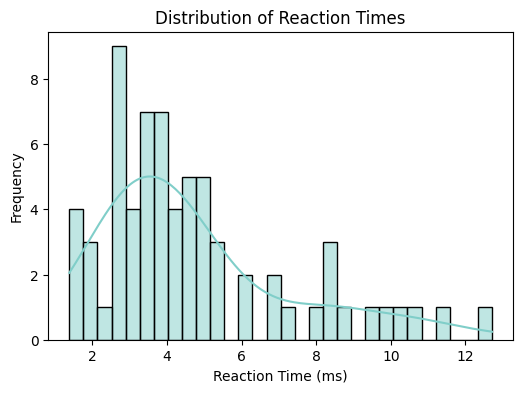

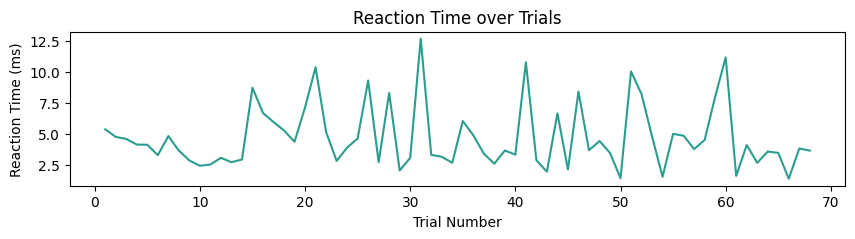

/tmp/ipykernel_3825935/3987600362.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='choice_key', y='rt', data=df, palette=COLORS['palette'])


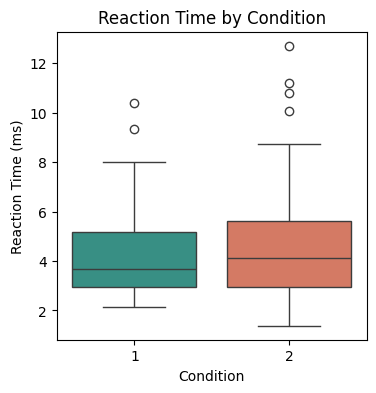

/tmp/ipykernel_3825935/3987600362.py:67: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['intercept'] = 1


T-statistic: -0.32, P-value: 0.7509
                            OLS Regression Results                            
Dep. Variable:                     rt   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                 -0.029
Method:                 Least Squares   F-statistic:                   0.05972
Date:                Tue, 17 Mar 2026   Prob (F-statistic):              0.942
Time:                        21:31:53   Log-Likelihood:                -160.31
No. Observations:                  68   AIC:                             326.6
Df Residuals:                      65   BIC:                             333.3
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      4

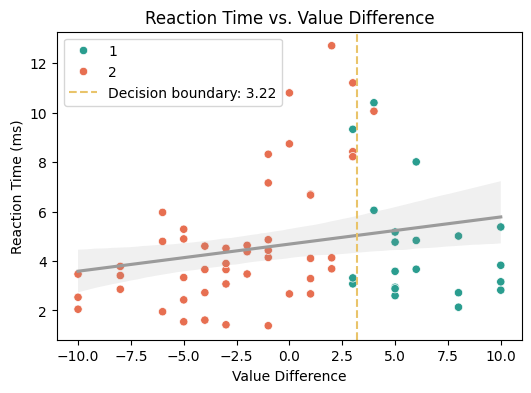

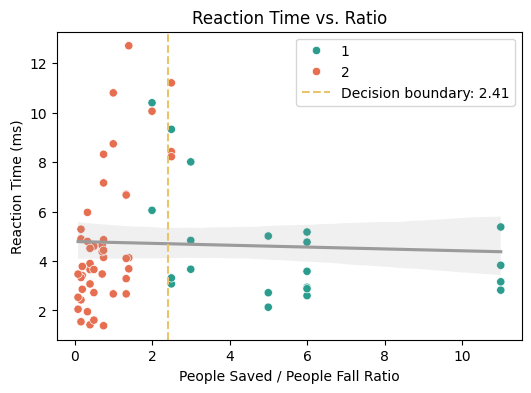

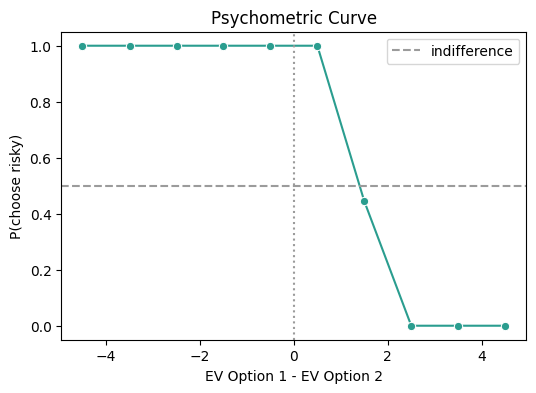

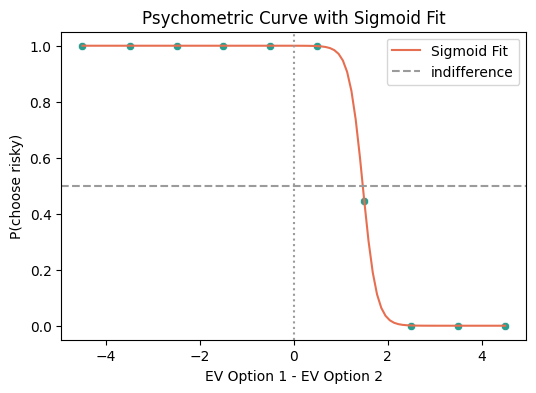

{'subject_id': '004',
 't_stat': np.float64(-0.3187201600080815),
 'p_value': np.float64(0.7509451911702263),
 'ols_summary': <class 'statsmodels.iolib.summary.Summary'>
 """
                             OLS Regression Results                            
 Dep. Variable:                     rt   R-squared:                       0.002
 Model:                            OLS   Adj. R-squared:                 -0.029
 Method:                 Least Squares   F-statistic:                   0.05972
 Date:                Tue, 17 Mar 2026   Prob (F-statistic):              0.942
 Time:                        21:31:55   Log-Likelihood:                -160.31
 No. Observations:                  68   AIC:                             326.6
 Df Residuals:                      65   BIC:                             333.3
 Df Model:                           2                                         
 Covariance Type:            nonrobust                                         
                  coef   

In [18]:
df = pd.read_csv('/usr/people/ad3758/neu502b/analysis/behavioral_analysis/sub-004.csv')
plot_rt_by_condition(df, '004')

/tmp/ipykernel_3825935/3987600362.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  psychometric = df.groupby('ev_bin')['chose_risky'].mean().reset_index()


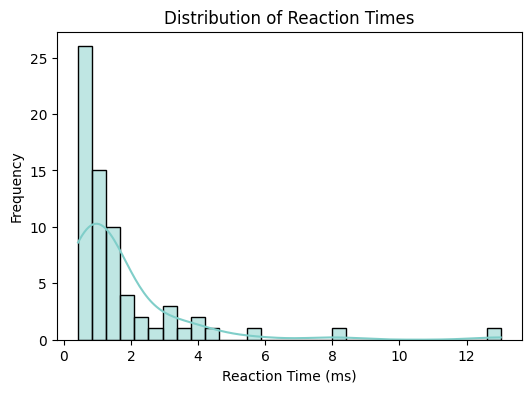

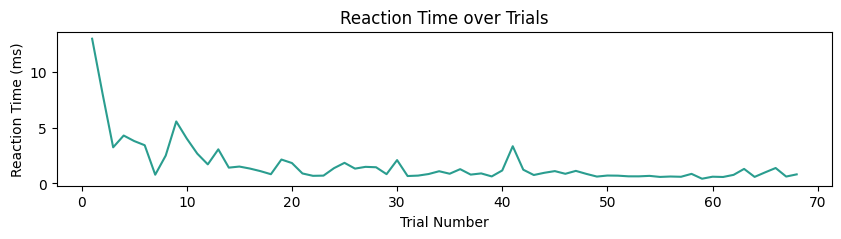

/tmp/ipykernel_3825935/3987600362.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='choice_key', y='rt', data=df, palette=COLORS['palette'])


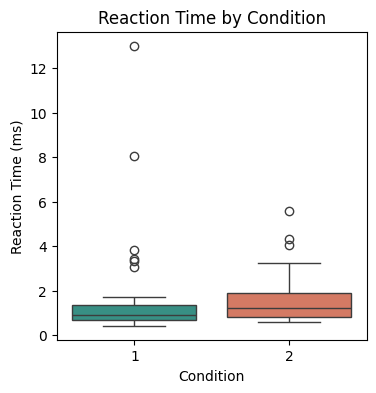

/tmp/ipykernel_3825935/3987600362.py:67: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['intercept'] = 1


T-statistic: 0.20, P-value: 0.8440
                            OLS Regression Results                            
Dep. Variable:                     rt   R-squared:                       0.076
Model:                            OLS   Adj. R-squared:                  0.048
Method:                 Least Squares   F-statistic:                     2.691
Date:                Tue, 17 Mar 2026   Prob (F-statistic):             0.0753
Time:                        21:32:05   Log-Likelihood:                -137.79
No. Observations:                  68   AIC:                             281.6
Df Residuals:                      65   BIC:                             288.2
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.

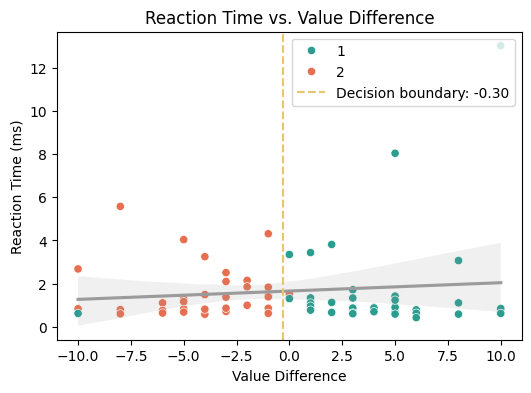

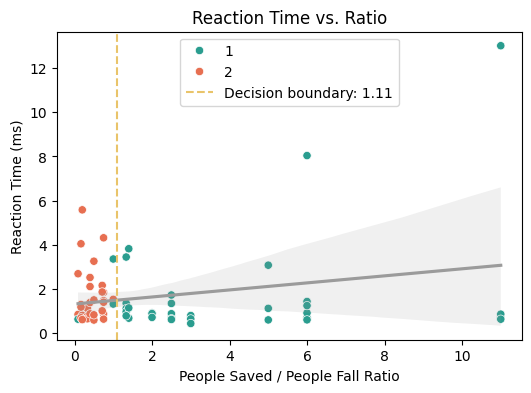

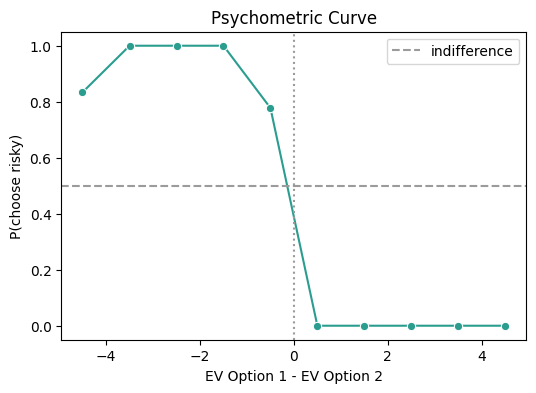

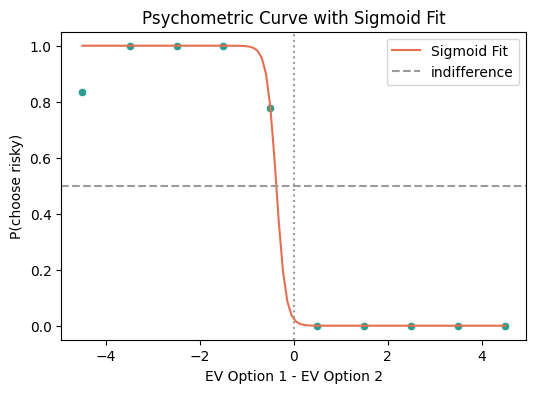

{'subject_id': '006',
 't_stat': np.float64(0.1976013527718195),
 'p_value': np.float64(0.8439643001982411),
 'ols_summary': <class 'statsmodels.iolib.summary.Summary'>
 """
                             OLS Regression Results                            
 Dep. Variable:                     rt   R-squared:                       0.076
 Model:                            OLS   Adj. R-squared:                  0.048
 Method:                 Least Squares   F-statistic:                     2.691
 Date:                Tue, 17 Mar 2026   Prob (F-statistic):             0.0753
 Time:                        21:32:07   Log-Likelihood:                -137.79
 No. Observations:                  68   AIC:                             281.6
 Df Residuals:                      65   BIC:                             288.2
 Df Model:                           2                                         
 Covariance Type:            nonrobust                                         
                  coef    

In [19]:
df = pd.read_csv('/usr/people/ad3758/neu502b/analysis/behavioral_analysis/sub-006.csv')
plot_rt_by_condition(df, '006')

/tmp/ipykernel_3825935/3987600362.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  psychometric = df.groupby('ev_bin')['chose_risky'].mean().reset_index()


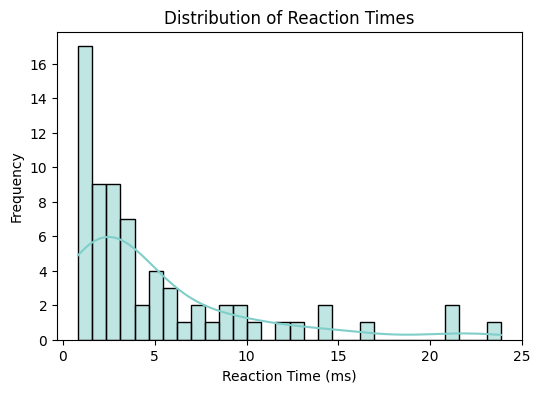

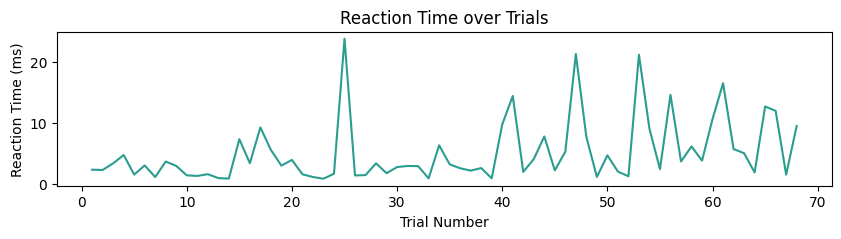

/tmp/ipykernel_3825935/3987600362.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='choice_key', y='rt', data=df, palette=COLORS['palette'])


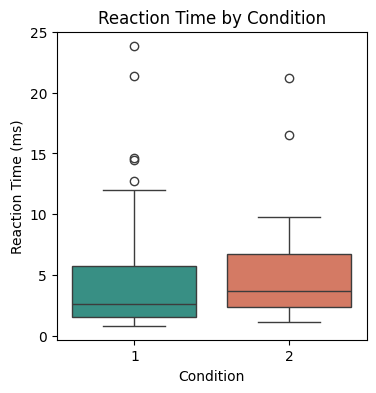

/tmp/ipykernel_3825935/3987600362.py:67: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['intercept'] = 1


T-statistic: -0.24, P-value: 0.8100
                            OLS Regression Results                            
Dep. Variable:                     rt   R-squared:                       0.147
Model:                            OLS   Adj. R-squared:                  0.121
Method:                 Least Squares   F-statistic:                     5.613
Date:                Tue, 17 Mar 2026   Prob (F-statistic):            0.00564
Time:                        21:32:23   Log-Likelihood:                -203.03
No. Observations:                  68   AIC:                             412.1
Df Residuals:                      65   BIC:                             418.7
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     10

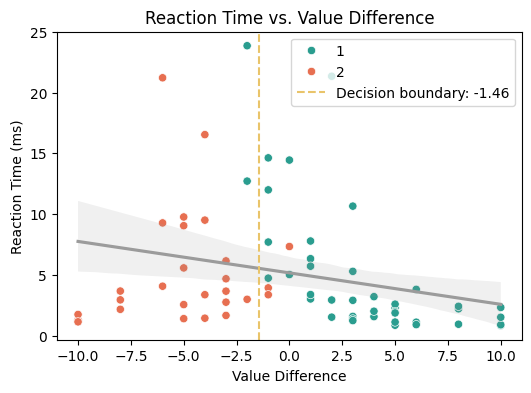

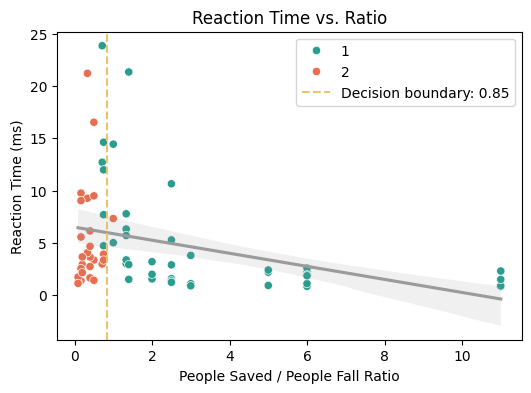

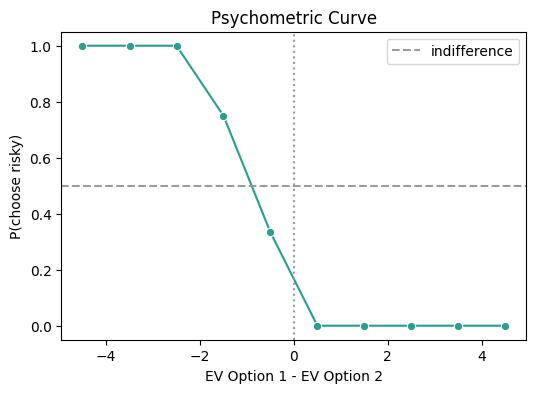

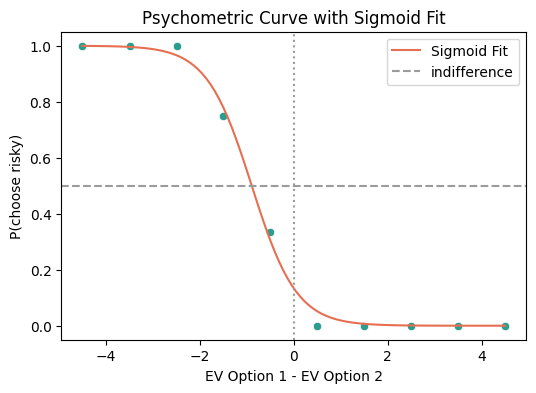

{'subject_id': '007',
 't_stat': np.float64(-0.2413279963987895),
 'p_value': np.float64(0.8100490952609629),
 'ols_summary': <class 'statsmodels.iolib.summary.Summary'>
 """
                             OLS Regression Results                            
 Dep. Variable:                     rt   R-squared:                       0.147
 Model:                            OLS   Adj. R-squared:                  0.121
 Method:                 Least Squares   F-statistic:                     5.613
 Date:                Tue, 17 Mar 2026   Prob (F-statistic):            0.00564
 Time:                        21:32:26   Log-Likelihood:                -203.03
 No. Observations:                  68   AIC:                             412.1
 Df Residuals:                      65   BIC:                             418.7
 Df Model:                           2                                         
 Covariance Type:            nonrobust                                         
                  coef   

In [20]:
df = pd.read_csv('/usr/people/ad3758/neu502b/analysis/behavioral_analysis/sub-007.csv')
plot_rt_by_condition(df, '007')

/tmp/ipykernel_3825935/3987600362.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  psychometric = df.groupby('ev_bin')['chose_risky'].mean().reset_index()


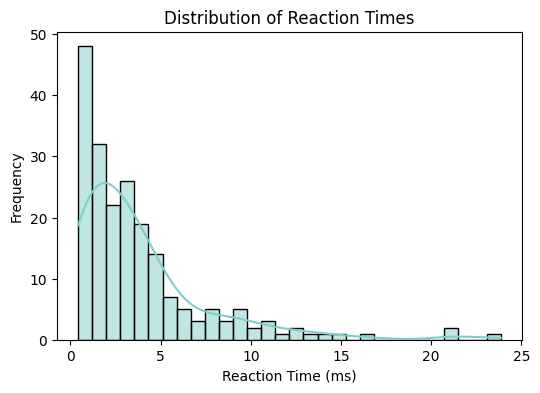

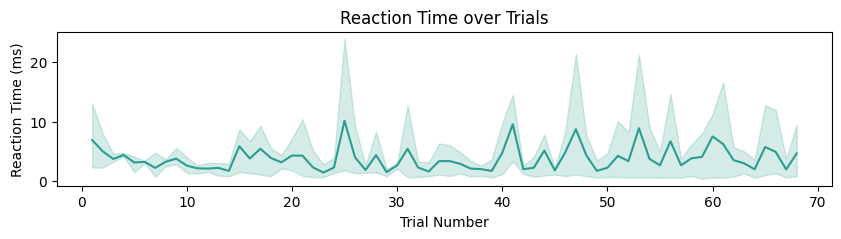

/tmp/ipykernel_3825935/3987600362.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='choice_key', y='rt', data=df, palette=COLORS['palette'])


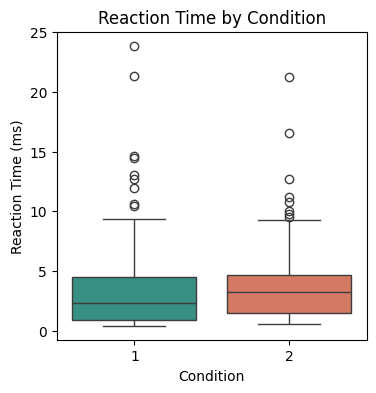

T-statistic: -0.49, P-value: 0.6242
                            OLS Regression Results                            
Dep. Variable:                     rt   R-squared:                       0.018
Model:                            OLS   Adj. R-squared:                  0.008
Method:                 Least Squares   F-statistic:                     1.813
Date:                Tue, 17 Mar 2026   Prob (F-statistic):              0.166
Time:                        21:32:31   Log-Likelihood:                -562.05
No. Observations:                 204   AIC:                             1130.
Df Residuals:                     201   BIC:                             1140.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      5

/tmp/ipykernel_3825935/3987600362.py:67: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['intercept'] = 1


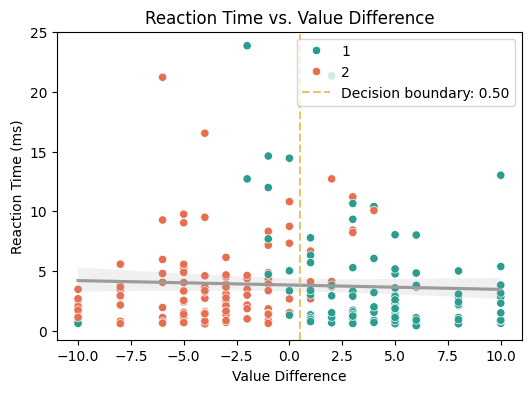

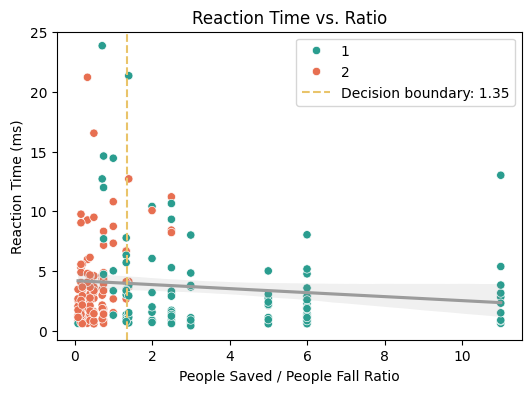

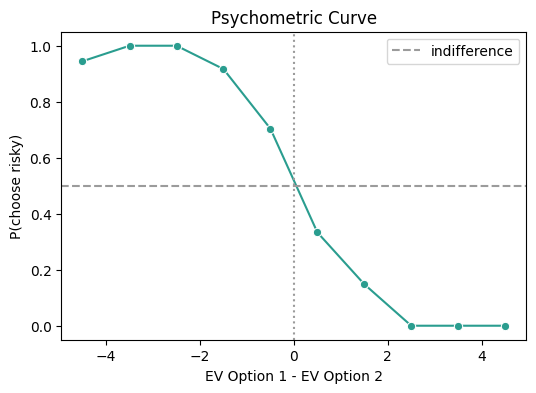

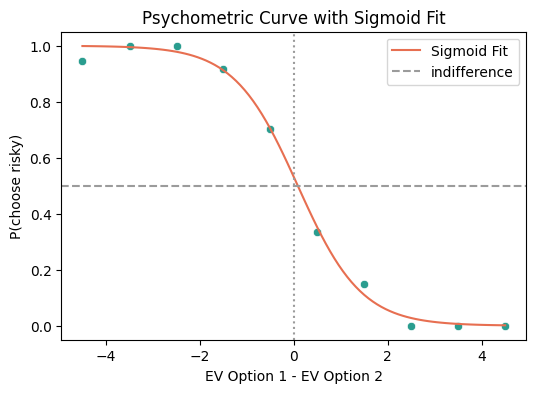

{'subject_id': 'combined',
 't_stat': np.float64(-0.4906569409530751),
 'p_value': np.float64(0.6242016809197717),
 'ols_summary': <class 'statsmodels.iolib.summary.Summary'>
 """
                             OLS Regression Results                            
 Dep. Variable:                     rt   R-squared:                       0.018
 Model:                            OLS   Adj. R-squared:                  0.008
 Method:                 Least Squares   F-statistic:                     1.813
 Date:                Tue, 17 Mar 2026   Prob (F-statistic):              0.166
 Time:                        21:32:32   Log-Likelihood:                -562.05
 No. Observations:                 204   AIC:                             1130.
 Df Residuals:                     201   BIC:                             1140.
 Df Model:                           2                                         
 Covariance Type:            nonrobust                                         
                  co

In [21]:
combined_df = pd.concat([
    pd.read_csv(f'/usr/people/ad3758/neu502b/analysis/behavioral_analysis/sub-{sub}.csv') 
    for sub in ['004', '006', '007']
]).reset_index(drop=True)

plot_rt_by_condition(combined_df, 'combined')